<a href="https://colab.research.google.com/github/Grzegorz-GG/DissertationPW/blob/main/Experiment40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import wandb
import joblib
import torchvision.transforms as transforms
from torchvision.transforms import v2

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import timm
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
gt_path = 'train_gt.csv'
wavelength_path = 'wavelengths.csv'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

output_dir = '/content/test_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/test.tar.gz -C {output_dir}

test/
test/77.npz
test/837.npz
test/189.npz
test/63.npz
test/823.npz
test/638.npz
test/610.npz
test/88.npz
test/176.npz
test/162.npz
test/604.npz
test/1145.npz
test/1151.npz
test/348.npz
test/374.npz
test/412.npz
test/406.npz
test/360.npz
test/599.npz
test/1019.npz
test/1031.npz
test/1025.npz
test/228.npz
test/200.npz
test/566.npz
test/572.npz
test/214.npz
test/943.npz
test/957.npz
test/758.npz
test/980.npz
test/994.npz
test/764.npz
test/770.npz
test/771.npz
test/765.npz
test/995.npz
test/981.npz
test/759.npz
test/956.npz
test/942.npz
test/573.npz
test/215.npz
test/201.npz
test/567.npz
test/229.npz
test/1024.npz
test/1030.npz
test/1018.npz
test/598.npz
test/407.npz
test/361.npz
test/375.npz
test/413.npz
test/349.npz
test/1150.npz
test/1144.npz
test/163.npz
test/605.npz
test/89.npz
test/611.npz
test/177.npz
test/639.npz
test/822.npz
test/62.npz
test/836.npz
test/76.npz
test/188.npz
test/60.npz
test/820.npz
test/74.npz
test/834.npz
test/48.npz
test/808.npz
test/149.npz
test/607.npz
test/

In [6]:
import os

output_dir = '/content/train_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/train.tar.gz -C {output_dir}

train/
train/77.npz
train/837.npz
train/189.npz
train/1409.npz
train/63.npz
train/823.npz
train/1347.npz
train/1421.npz
train/1435.npz
train/1353.npz
train/638.npz
train/610.npz
train/1384.npz
train/88.npz
train/176.npz
train/162.npz
train/1390.npz
train/604.npz
train/1179.npz
train/1623.npz
train/1145.npz
train/1151.npz
train/1637.npz
train/348.npz
train/374.npz
train/1186.npz
train/412.npz
train/406.npz
train/1192.npz
train/360.npz
train/599.npz
train/1019.npz
train/1031.npz
train/1025.npz
train/228.npz
train/200.npz
train/566.npz
train/572.npz
train/214.npz
train/943.npz
train/1569.npz
train/957.npz
train/1233.npz
train/1555.npz
train/1541.npz
train/1227.npz
train/758.npz
train/980.npz
train/994.npz
train/764.npz
train/1596.npz
train/1582.npz
train/770.npz
train/1583.npz
train/771.npz
train/765.npz
train/1597.npz
train/995.npz
train/981.npz
train/759.npz
train/1540.npz
train/1226.npz
train/1232.npz
train/1554.npz
train/956.npz
train/942.npz
train/1568.npz
train/573.npz
train/215.npz

In [7]:
gt_df = pd.read_csv(gt_path)
wavelength_df = pd.read_csv(wavelength_path)

In [8]:
def load_data(directory: str):
    data = []

    all_files = np.array(
        sorted(
            glob(os.path.join(directory, "*.npz")),
            key=lambda x: int(os.path.basename(x).replace(".npz", "")),
        )
    )

    for file_name in all_files:
        with np.load(file_name) as npz:
            raw_arr = np.ma.MaskedArray(data=npz['data'], mask=npz['mask'])
            img_tensor = torch.as_tensor(raw_arr.data, dtype=torch.float32)
            mask = ~torch.as_tensor(raw_arr.mask)  # 1 = valid, 0 = invalid
        data.append((img_tensor, mask))

    return data


In [9]:
def load_gt(file_path: str):
    """Load labels for train set from the ground truth file.
    Args:
        file_path (str): Path to the ground truth .csv file.
    Returns:
        [type]: 2D numpy array with soil properties levels
    """
    gt_file = pd.read_csv(file_path)
    labels = gt_file[["P", "K", "Mg", "pH"]].values
    return labels

In [10]:
X_train = load_data("/content/train_data/train")
y_train = load_gt("train_gt.csv")

In [11]:
def collect_valid_pixels(data_list, max_pixels=10000000):
    """
    Collect only valid (non-masked) pixels from all patches for PCA fitting.
    Excluding zero-padded invalid pixels prevents biasing the StandardScaler and PCA.
    """
    all_pixels = []
    total_potential_pixels = sum(x.shape[1] * x.shape[2] for x, mask in data_list)

    sampling_ratio = 1.0
    if total_potential_pixels > max_pixels:
        sampling_ratio = max_pixels / total_potential_pixels
        print(f"Sampling {sampling_ratio*100:.2f}% of pixels to stay within {max_pixels} limit.")

    for x, mask in data_list:
        data_np = x.numpy()  # (C, H, W)
        mask_np = mask[0].numpy().astype(bool)  # (H, W) spatial validity mask

        pixels = np.transpose(data_np, (1, 2, 0)).reshape(-1, data_np.shape[0])  # (H*W, C)
        valid_flat = mask_np.flatten()
        valid_pixels = pixels[valid_flat]  # only valid pixels

        if valid_pixels.shape[0] == 0:
            continue

        if sampling_ratio < 1.0:
            n_sample = max(1, int(valid_pixels.shape[0] * sampling_ratio))
            idx = np.random.choice(valid_pixels.shape[0], n_sample, replace=False)
            all_pixels.append(valid_pixels[idx])
        else:
            all_pixels.append(valid_pixels)

    if not all_pixels:
        return np.empty((0, data_list[0][0].shape[0]))
    return np.vstack(all_pixels)


In [12]:
def transform_patches_with_mask(data_list, scaler, pca):
    """
    Transforms a list of (tensor, mask) tuples using a fitted StandardScaler and PCA.
    Invalid pixels are zeroed out in the PCA output to prevent artifacts.

    Returns list of (pca_tensor, pca_mask) tuples.
      pca_tensor: (n_components, H, W) float32
      pca_mask:   (n_components, H, W) bool, 1 = valid
    """
    transformed_list = []
    for x, mask in data_list:
        data_np = x.numpy()  # (C, H, W)
        C, H, W = data_np.shape
        pixels = np.transpose(data_np, (1, 2, 0)).reshape(-1, C)  # (H*W, C)

        pixels_scaled = scaler.transform(pixels)
        pixels_pca = pca.transform(pixels_scaled)
        data_pca = pixels_pca.reshape(H, W, -1)

        tensor_pca = torch.from_numpy(np.transpose(data_pca, (2, 0, 1)).astype(np.float32))

        # Expand the spatial validity mask to match PCA output channels
        n_components = tensor_pca.shape[0]
        spatial_mask = mask[0]  # (H, W) bool
        pca_mask = spatial_mask.unsqueeze(0).expand(n_components, -1, -1).clone()  # (n_comp, H, W)

        # Zero out invalid pixels so padding does not corrupt feature statistics
        tensor_pca = tensor_pca * pca_mask.float()

        transformed_list.append((tensor_pca, pca_mask))
    return transformed_list


In [ ]:
# # -----------------------
# # Split into train, val, test
# # -----------------------

# # First, split off test set (20%)
# X_temp, X_test, y_temp, y_test = train_test_split(
#     X_train, y_train, test_size=0.2, random_state=42
# )

# # Then, split remaining 80% into train/val
# X_train_final, X_val, y_train_final, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.2, random_state=42
# )

# print(f"Train patches: {len(X_train_final)}")
# print(f"Validation patches: {len(X_val)}")
# print(f"Test patches: {len(X_test)}")

In [14]:
# -----------------------
# Split into train, val, test
# -----------------------

# Create an array of indices for X_train
original_indices = np.arange(len(X_train))

# First, split off test set (20%)
X_temp, X_test, y_temp, y_test, temp_indices, test_indices = train_test_split(
    X_train, y_train, original_indices, test_size=0.2, random_state=93
)

# Then, split remaining 80% into train (60%) / val (20%) of total
# 0.25 * 80% = 20% of the full dataset
X_train_final, X_val, y_train_final, y_val, train_indices, val_indices = train_test_split(
    X_temp, y_temp, temp_indices, test_size=0.25, random_state=93
)

print(f"Train patches: {len(X_train_final)}")
print(f"Validation patches: {len(X_val)}")
print(f"Test patches: {len(X_test)}")


Train patches: 1038
Validation patches: 347
Test patches: 347


In [ ]:
# # Load PCA instead of refitting
# pca = joblib.load("pca_hyperspectral.pkl")
# print("PCA loaded from file")

# scaler = joblib.load("scaler_hyperspectral.pkl")
# print("Scaler loaded from file")

In [16]:
# Fit PCA on valid training pixels only
X_pixels_train = collect_valid_pixels(X_train_final)
print(f"Collected {X_pixels_train.shape[0]:,} valid training pixels ({X_pixels_train.shape[1]} channels)")

scaler = StandardScaler()
X_pixels_train_scaled = scaler.fit_transform(X_pixels_train)

joblib.dump(scaler, "scaler_hyperspectral.pkl")
print("Scaler saved.")

n_components = 3
pca = PCA(n_components=n_components)
pca.fit(X_pixels_train_scaled)

joblib.dump(pca, "pca_hyperspectral.pkl")
print(f"PCA saved. Explained variance: {pca.explained_variance_ratio_.sum():.4f}")


Collected 3,441,313 valid training pixels (150 channels)
Scaler saved.
PCA saved. Explained variance: 0.9959


In [17]:
X_train_pca = transform_patches_with_mask(X_train_final, scaler, pca)
X_val_pca   = transform_patches_with_mask(X_val, scaler, pca)
X_test_pca  = transform_patches_with_mask(X_test, scaler, pca)

In [18]:
# ------------------------------------------------------------------
# Compute global per-channel statistics on PCA-transformed training
# data (valid pixels only) used for consistent normalization.
# ------------------------------------------------------------------
def _pad_to_size_static(x, mask, size=(224, 224)):
    _, h, w = x.shape
    th, tw = size
    if h > th:
        sh = (h - th) // 2
        x, mask = x[:, sh:sh + th, :], mask[:, sh:sh + th, :]
        h = th
    if w > tw:
        sw = (w - tw) // 2
        x, mask = x[:, :, sw:sw + tw], mask[:, :, sw:sw + tw]
        w = tw
    pad_h, pad_w = th - h, tw - w
    pt, pl = pad_h // 2, pad_w // 2
    x    = F.pad(x,    (pl, pad_w - pl, pt, pad_h - pt), value=0)
    mask = F.pad(mask, (pl, pad_w - pl, pt, pad_h - pt), value=0)
    return x, mask

def calculate_global_stats(X_data, pad_fn):
    print("Calculating global per-channel stats from PCA-transformed training data...")
    n_ch = X_data[0][0].shape[0]
    channel_data = [[] for _ in range(n_ch)]
    for x_item, mask_item in tqdm(X_data, desc="Computing global stats"):
        xp, mp = pad_fn(x_item, mask_item)
        for c in range(n_ch):
            channel_data[c].extend(xp[c][mp[c]].cpu().numpy())
    global_means = torch.tensor([np.mean(cd) for cd in channel_data], dtype=torch.float32)
    global_stds  = torch.tensor([np.std(cd)  for cd in channel_data], dtype=torch.float32)
    print(f"Global Means: {global_means}")
    print(f"Global Stds:  {global_stds}")
    return global_means, global_stds

global_means, global_stds = calculate_global_stats(X_train_pca, _pad_to_size_static)


Calculating global per-channel stats from PCA-transformed training data...


Computing global stats: 100%|██████████| 1038/1038 [00:01<00:00, 974.69it/s]


Global Means: tensor([ 1.3878e-03,  5.2803e-04, -2.3505e-05])
Global Stds:  tensor([10.1110,  6.8085,  0.9034])


In [19]:
# -------------------------------
# Scale labels
# -------------------------------
scaler_y = StandardScaler()
y_train_final_scaled = scaler_y.fit_transform(y_train_final)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)
joblib.dump(scaler_y, "scaler_labels.pkl")
print("Label scaler saved.")

Label scaler saved.


In [20]:
class RandomSpectralDrop:
    """Zero out random spectral channels to prevent over-reliance on specific bands."""
    def __init__(self, drop_prob=0.05):
        self.drop_prob = drop_prob

    def __call__(self, x):
        keep = torch.bernoulli(torch.ones(x.shape[0]) * (1 - self.drop_prob))
        return x * keep.view(-1, 1, 1)

class RandomRotate90:
    def __call__(self, x):
        k = torch.randint(0, 4, (1,)).item()
        return torch.rot90(x, k, dims=(-2, -1))


class NPZDataset(Dataset):
    def __init__(self, tensor_list, labels=None, augment=True, size=(224, 224),
                 global_means=None, global_stds=None):
        """
        tensor_list: list of (x, mask) tuples
                     x:    (n_components, H, W) PCA-transformed float tensor
                     mask: (n_components, H, W) bool, 1 = valid
        """
        self.tensor_list  = tensor_list
        self.labels       = labels
        self.augment      = augment
        self.size         = size
        self.global_means = global_means
        self.global_stds  = global_stds

        self.transform_aug = v2.Compose([
            v2.RandomResizedCrop(size=self.size, scale=(0.8, 1.0)),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.5),
            RandomRotate90(),
            RandomSpectralDrop(drop_prob=0.05)
        ])

    def __len__(self):
        return len(self.tensor_list)

    def pad_to_size(self, x, mask):
        _, h, w = x.shape
        th, tw = self.size
        if h > th:
            sh = (h - th) // 2
            x, mask = x[:, sh:sh + th, :], mask[:, sh:sh + th, :]
            h = th
        if w > tw:
            sw = (w - tw) // 2
            x, mask = x[:, :, sw:sw + tw], mask[:, :, sw:sw + tw]
            w = tw
        pad_h, pad_w = th - h, tw - w
        pt, pl = pad_h // 2, pad_w // 2
        x    = F.pad(x,    (pl, pad_w - pl, pt, pad_h - pt), value=0)
        mask = F.pad(mask, (pl, pad_w - pl, pt, pad_h - pt), value=0)
        return x, mask

    def normalize_with_mask(self, x, mask):
        if self.global_means is not None and self.global_stds is not None:
            x_norm = (x - self.global_means.to(x.device).view(-1, 1, 1)) / \
                     (self.global_stds.to(x.device).view(-1, 1, 1) + 1e-6)
        else:
            x_norm = x
        return x_norm * mask.float()

    def __getitem__(self, idx):
        x, mask = self.tensor_list[idx]

        x, mask = self.pad_to_size(x, mask)
        num_valid_pixels = mask[0].sum().float()

        x = self.normalize_with_mask(x, mask)

        if self.augment and self.labels is not None:
            x = self.transform_aug(x)
            x = x * mask.float()  # re-zero invalid pixels after spatial augmentation

        if self.labels is not None:
            y = torch.tensor(self.labels[idx], dtype=torch.float32)
            return x, num_valid_pixels, y
        else:
            return x, num_valid_pixels


In [21]:
train_dataset = NPZDataset(X_train_pca, y_train_final_scaled, augment=True,
                           global_means=global_means, global_stds=global_stds)
val_dataset   = NPZDataset(X_val_pca,   y_val_scaled,         augment=False,
                           global_means=global_means, global_stds=global_stds)
test_dataset  = NPZDataset(X_test_pca,  y_test_scaled,        augment=False,
                           global_means=global_means, global_stds=global_stds)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


In [22]:
class HyperspectralRegressor(nn.Module):
    def __init__(self, in_channels=10, n_outputs=4,
                 backbone_name="convnext_small_in22k", pretrained=True, dropout=0.3):
        """
        Hyperspectral regression model using PCA-reduced inputs and a ConvNeXt backbone.
        Spectral reduction is handled upstream by PCA; no 1x1 conv reducer needed.
        """
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            in_chans=in_channels,
            num_classes=0,
        )

        feat_dim = getattr(self.backbone, "num_features", None)
        if feat_dim is None:
            raise RuntimeError("Cannot determine backbone feature dimension from num_features")

        self.regressor = nn.Sequential(
            nn.Linear(feat_dim + 1, 256),  # +1 for log(valid_pixels) size feature
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_outputs),
        )

    def forward(self, x, num_valid_pixels):
        """
        x:                (B, in_channels, H, W) -- padded/invalid pixels are zero
        num_valid_pixels: (B,) count of valid (non-padded) pixels per patch
        """
        features  = self.backbone(x)                                       # (B, feat_dim)
        size_feat = torch.log1p(num_valid_pixels.float()) / 10.0           # (B,)
        features  = torch.cat([features, size_feat.unsqueeze(1)], dim=1)  # (B, feat_dim+1)
        return self.regressor(features)                                    # (B, n_outputs)


Test overfitting on one batch

In [23]:
train_data_single_batch = next(iter(train_loader))

In [24]:
train_data_single_batch[0].shape

torch.Size([32, 3, 224, 224])

In [ ]:
# DataLoader now returns (x, num_valid_pixels, y) three-element tuples
x_batch, nv_batch, y_batch = train_data_single_batch
print("x shape:              ", x_batch.shape)
print("num_valid_pixels shape:", nv_batch.shape)
print("y shape:              ", y_batch.shape)


In [ ]:
model_overfit = HyperspectralRegressor(
    in_channels=10,
    n_outputs=4,
    backbone_name="convnext_small_in22k",
    pretrained=True
)
model_overfit = model_overfit.to(device)

optimizer_overfit = optim.AdamW([
    {"params": model_overfit.backbone.parameters(),  "lr": 1e-5},
    {"params": model_overfit.regressor.parameters(), "lr": 1e-4},
], weight_decay=1e-4)
criterion_overfit = nn.MSELoss()

x_single, nv_single, y_single = train_data_single_batch
x_single  = x_single.to(device)
nv_single = nv_single.to(device)
y_single  = y_single.to(device)

overfit_epochs = 500
print(f"\n--- Overfitting on single batch for {overfit_epochs} epochs ---")
for ep in range(overfit_epochs):
    model_overfit.train()
    optimizer_overfit.zero_grad()
    out  = model_overfit(x_single, nv_single)
    loss = criterion_overfit(out, y_single)
    loss.backward()
    optimizer_overfit.step()
    if (ep + 1) % 50 == 0 or ep == 0:
        print(f"Epoch {ep+1:4d}/{overfit_epochs}  Loss: {loss.item():.6f}")
print("--- Overfitting complete ---")


In [ ]:
print('\n--- Model Overfit Predictions vs. True Values ---')
model_overfit.eval()
with torch.no_grad():
    outputs_single_batch = model_overfit(x_single, nv_single)
print("Predictions:")
print(outputs_single_batch.cpu().numpy())
print("\nTrue Values:")
print(y_single.cpu().numpy())


In [ ]:
# Load the label scaler
scaler_y = joblib.load("scaler_labels.pkl")
print("Label scaler loaded.")

print('\n--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---')
# Inverse transform predictions and true values
unscaled_predictions = scaler_y.inverse_transform(outputs_single_batch.cpu().numpy())
unscaled_true_values = scaler_y.inverse_transform(y_single.cpu().numpy())

print("Unscaled Predictions:")
print(unscaled_predictions)
print("\nUnscaled True Values:")
print(unscaled_true_values)

Label scaler loaded.

--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---
Unscaled Predictions:
[[ 78.156624  227.85376   131.45029     7.345134 ]
 [ 80.96331   313.8164    203.08694     6.392324 ]
 [ 44.318188  204.75436   129.17343     6.8054852]
 [ 59.166393  156.4823    128.17487     6.888204 ]
 [ 58.07237   207.25107   149.87573     6.5975394]
 [ 49.987087  214.15082   164.92479     6.7937064]
 [ 71.69137   257.3669    149.84464     7.002677 ]
 [ 91.93386   325.01007   147.43697     6.988344 ]
 [ 90.571594  235.1085    131.5632      7.1201477]
 [ 82.26952   256.53735   182.70236     6.798571 ]
 [ 43.06945   197.66403   156.2106      6.896402 ]
 [ 39.772472  150.6009    116.69451     6.394775 ]
 [ 57.47321   195.02856   179.73457     6.9998636]
 [ 48.282722  208.16805   244.3986      6.774398 ]
 [ 67.744965  281.17957   157.56262     6.8039856]
 [ 63.08623   263.75052   134.71143     6.8082743]]

Unscaled True Values:
[[ 77.8 227.  136.    7.3]
 [ 81.4 315.  203.   

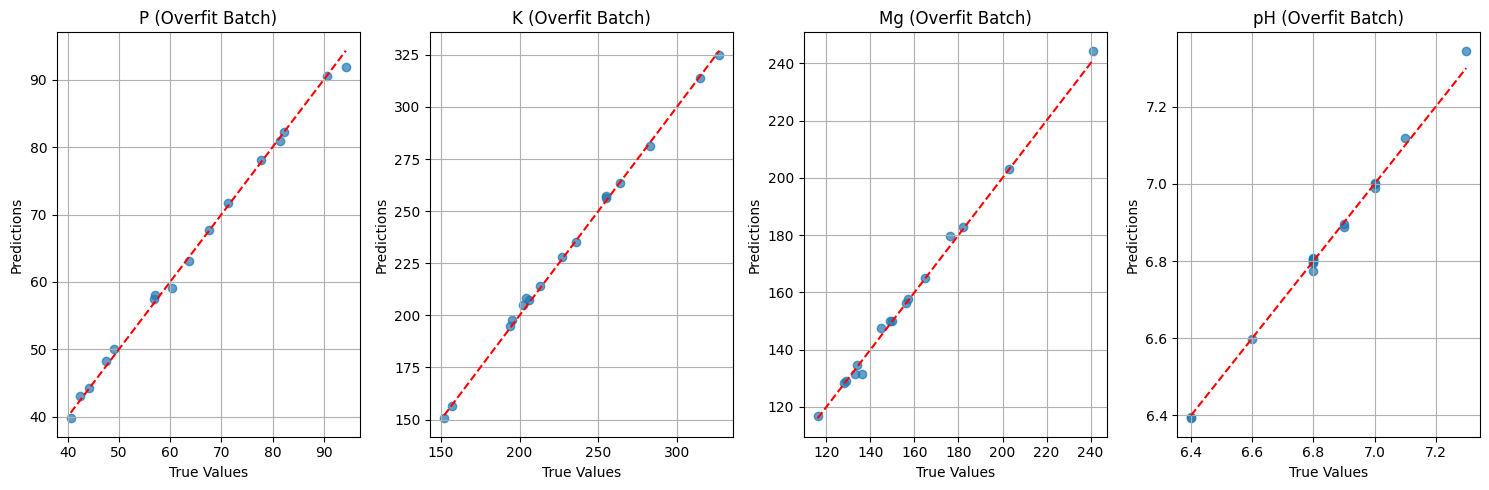

In [ ]:

plt.figure(figsize=(15, 5))

metrics = ['P', 'K', 'Mg', 'pH']
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1) # 1 row, 4 columns
    plt.scatter(unscaled_true_values[:, i], unscaled_predictions[:, i], alpha=0.7)
    plt.plot([min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             [min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             'r--') # Red dashed line for ideal prediction
    plt.title(f'{metric} (Overfit Batch)')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.grid(True)

plt.tight_layout()
plt.show()


Learning loop

In [25]:
def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    device,
    epochs=120,
    warmup_epochs=10,
    patience=13,
    save_path="best_hyperspectral_model.pth",
    max_grad_norm=1.0,
    wandb_run=None
):
    initial_lrs    = [pg['lr'] for pg in optimizer.param_groups]
    best_val_loss  = float('inf')
    early_stop_ctr = 0

    for epoch in range(epochs):
        # ---- Warm-up ----
        if epoch < warmup_epochs:
            wf = (epoch + 1) / float(warmup_epochs)
            for i, pg in enumerate(optimizer.param_groups):
                pg['lr'] = initial_lrs[i] * wf

        # ---- Train ----
        model.train()
        train_loss_sum, n_train = 0.0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for xb, nv_b, yb in loop:
            xb, nv_b, yb = xb.to(device), nv_b.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb, nv_b)
            loss  = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            bsz = xb.size(0)
            train_loss_sum += loss.item() * bsz
            n_train += bsz
            loop.set_postfix(loss=loss.item())
        train_loss = train_loss_sum / max(1, n_train)

        # ---- Validate ----
        model.eval()
        val_loss_sum, n_val = 0.0, 0
        with torch.no_grad():
            for xv, nv_v, yv in val_loader:
                xv, nv_v, yv = xv.to(device), nv_v.to(device), yv.to(device)
                vpreds = model(xv, nv_v)
                bsz = xv.size(0)
                val_loss_sum += criterion(vpreds, yv).item() * bsz
                n_val += bsz
        val_loss = val_loss_sum / max(1, n_val)

        # ---- Scheduler (after warmup) ----
        if epoch >= warmup_epochs:
            scheduler.step(val_loss)

        current_lrs = [pg['lr'] for pg in optimizer.param_groups]
        print(f"Epoch {epoch+1:3d}/{epochs}  Train: {train_loss:.4f}  Val: {val_loss:.4f}"
              f"  LR backbone: {current_lrs[0]:.2e}  LR head: {current_lrs[1]:.2e}")

        if wandb_run is not None:
            wandb_run.log({"train_loss": train_loss, "val_loss": val_loss, "epoch": epoch + 1,
                           "lr_backbone": current_lrs[0], "lr_head": current_lrs[1]})

        # ---- Early stopping & checkpoint ----
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            early_stop_ctr = 0
            torch.save(model.state_dict(), save_path)
        else:
            early_stop_ctr += 1
            if early_stop_ctr >= patience:
                print(f"Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.4f})")
                break

    model.load_state_dict(torch.load(save_path))
    print(f"Best model loaded (val loss: {best_val_loss:.4f})")
    return model


In [26]:

# ---- Model ----
model = HyperspectralRegressor(
    in_channels=3,
    n_outputs=4,
    backbone_name="convnext_small_in22k",
    pretrained=True
)
model = model.to(device)

# ---- Optimizer (lower LR for pretrained backbone) ----
optimizer = optim.AdamW([
    {"params": model.backbone.parameters(),  "lr": 1e-5},
    {"params": model.regressor.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

# ---- Loss ----
criterion = nn.MSELoss()

# ---- Scheduler ----
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=6,
    min_lr=1e-6
)

# ---- Hyperparameters ----
epochs        = 90
patience      = 13
warmup_epochs = 10

# ---- W&B ----
wandb.init(
    project="hyperview_challenge PCA + convnext_small_in22k pretrained",
    config={
        "lr_backbone": 1e-5,
        "lr_head": 1e-4,
        "weight_decay": 1e-4,
        "epochs": epochs,
        "batch_size": 32,
        "optimizer": "AdamW",
        "criterion": "MSELoss",
        "backbone": "convnext_small_in22k",
        "pca_components": n_components,
        "scheduler": "ReduceLROnPlateau",
        "scheduler_factor": 0.3,
        "scheduler_patience": 6,
        "min_lr": 1e-6,
        "warmup_epochs": warmup_epochs,
        "early_stopping_patience": patience,
    }
)
wandb.run.log({"note": (
    "PCA spectral reduction (3 components, valid-pixel-only fit), "
    "global normalization on valid pixels, pad/crop to 224x224 (no resize distortion), "
    "ConvNeXt Small in22k pretrained, valid-pixel size feature, gradient clipping."
)})


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name convnext_small_in22k to current convnext_small.fb_in22k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ggasowski977 (ggasowski977-politechnika-warszawska) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [27]:
train_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device,
    epochs=epochs,
    warmup_epochs=warmup_epochs,
    patience=patience,
    save_path="best_hyperspectral_model.pth",
    max_grad_norm=1.0,
    wandb_run=wandb.run
)
wandb.finish()


Epoch   1/90  Train: 1.0011  Val: 1.1958  LR backbone: 1.00e-06  LR head: 1.00e-05


Epoch   2/90  Train: 0.9944  Val: 1.1883  LR backbone: 2.00e-06  LR head: 2.00e-05


Epoch   3/90  Train: 0.9864  Val: 1.1754  LR backbone: 3.00e-06  LR head: 3.00e-05


Epoch   4/90  Train: 0.9746  Val: 1.1609  LR backbone: 4.00e-06  LR head: 4.00e-05


Epoch   5/90  Train: 0.9620  Val: 1.1443  LR backbone: 5.00e-06  LR head: 5.00e-05


...

Epoch  41/90  Train: 0.6875  Val: 1.0174  LR backbone: 3.00e-06  LR head: 3.00e-05


Epoch  42/90  Train: 0.6849  Val: 1.0130  LR backbone: 3.00e-06  LR head: 3.00e-05


Epoch  43/90  Train: 0.7026  Val: 1.0158  LR backbone: 3.00e-06  LR head: 3.00e-05


Epoch  44/90  Train: 0.6813  Val: 1.0214  LR backbone: 3.00e-06  LR head: 3.00e-05
Early stopping at epoch 44 (best val loss: 1.0121)
Best model loaded (val loss: 1.0121)


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr_backbone,▁▂▃▃▄▅▆▆▇█████████████████████████▃▃▃▃▃▃
lr_head,▁▂▃▃▄▅▆▆▇█████████████████████████▃▃▃▃▃▃
train_loss,███▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
val_loss,██▇▇▆▆▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▂▁▂▁▁▁▁▁▁
epoch,44
lr_backbone,0.0
lr_head,3e-05
note,PCA spectral reducti...
train_loss,0.68131
val_loss,1.02141


Evaluate results in comparision to the Baseline Regressor.

In [28]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self

    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)


class SpectralCurveFiltering():
    """
    Create a histogram (a spectral curve) of a 3D cube, using the merge_function
    to aggregate all pixels within one band. The return array will have
    the shape of [CHANNELS_COUNT]
    """

    def __init__(self, merge_function = np.mean):
        self.merge_function = merge_function

    def __call__(self, sample: np.ndarray):
        return self.merge_function(sample, axis=(1, 2))

In [29]:
def evaluate_dl_model(model, test_loader, scaler_y, device):
    model.eval()
    test_predictions_scaled = []
    y_true_scaled = []

    with torch.no_grad():
        for X_batch, nv_batch, y_batch in test_loader:
            X_batch  = X_batch.to(device)
            nv_batch = nv_batch.to(device)
            preds    = model(X_batch, nv_batch)
            test_predictions_scaled.append(preds.cpu().numpy())
            y_true_scaled.append(y_batch.cpu().numpy())

    y_pred_scaled = np.vstack(test_predictions_scaled)
    y_true_sc     = np.vstack(y_true_scaled)

    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_true_sc)
    mse    = np.mean((y_true - y_pred) ** 2, axis=0)
    return y_pred, y_true, mse

def evaluate_baseline_regressor(baseline_regressor, X_test_filtered, y_test_true):
    preds = baseline_regressor.predict(X_test_filtered)
    mse   = np.mean((y_test_true - preds) ** 2, axis=0)
    return preds, mse

def calculate_and_print_results(model_mse, baseline_mse, y_true, y_pred, baseline_preds):
    score = np.mean(model_mse / baseline_mse)
    for i, name in enumerate(["P", "K", "Mg", "pH"]):
        print(f"{name}: Model MSE={model_mse[i]:.4f}  Baseline MSE={baseline_mse[i]:.4f}"
              f"  Normalized={model_mse[i]/baseline_mse[i]:.4f}")
    print(f"\nChallenge score (lower is better): {score:.4f}")

    plt.figure(figsize=(15, 5))
    for i, name in enumerate(["P", "K", "Mg", "pH"]):
        plt.subplot(1, 4, i + 1)
        plt.scatter(y_true[:, i], y_pred[:, i],         alpha=0.7, label='DL Model')
        plt.scatter(y_true[:, i], baseline_preds[:, i], alpha=0.7, label='Baseline', marker='x')
        lo = min(y_true[:, i].min(), y_pred[:, i].min())
        hi = max(y_true[:, i].max(), y_pred[:, i].max())
        plt.plot([lo, hi], [lo, hi], 'r--')
        plt.title(name); plt.xlabel('True'); plt.ylabel('Predicted')
        plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()


In [30]:
# Get true y values from the local test dataset (inverse-scaled)
y_test_scaled_true = np.array([test_dataset[i][2].numpy() for i in range(len(test_dataset))])
y_test_true = scaler_y.inverse_transform(y_test_scaled_true)


In [31]:
# X_train contains (tensor, mask) tuples — extract only the tensor for baseline
X_test_nonpca = [X_train[i][0] for i in test_indices]

filtering = SpectralCurveFiltering()
X_test_filtered = np.array([filtering(cube.cpu().numpy()) for cube in X_test_nonpca])

combined_train_val_indices = train_indices.tolist() + val_indices.tolist()
X_combined_train_val_nonpca = [X_train[i][0] for i in combined_train_val_indices]
y_combined_train_val_nonpca = y_train[combined_train_val_indices]

X_combined_train_val_filtered = np.array(
    [filtering(cube.cpu().numpy()) for cube in X_combined_train_val_nonpca]
)


In [32]:
baseline_reg_current = BaselineRegressor() # Initialize a new baseline regressor
baseline_reg_current = baseline_reg_current.fit(X_combined_train_val_filtered, y_combined_train_val_nonpca)

baseline_preds_test = baseline_reg_current.predict(X_test_filtered)

In [33]:
model.load_state_dict(torch.load("best_hyperspectral_model.pth"))
model.eval()

test_predictions_scaled = []
with torch.no_grad():
    for X_batch, nv_batch, _ in test_loader:
        X_batch  = X_batch.to(device)
        nv_batch = nv_batch.to(device)
        preds    = model(X_batch, nv_batch)
        test_predictions_scaled.append(preds.cpu().numpy())

y_test_scaled_pred = np.vstack(test_predictions_scaled)
y_test_pred        = scaler_y.inverse_transform(y_test_scaled_pred)


In [34]:
# -----------------------------
# Compute MSE per target
# -----------------------------
model_mse_targets = np.mean((y_test_true - y_test_pred)**2, axis=0)
baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)

# Compute normalized score (challenge metric)
challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

# -----------------------------
# Print per-target comparison
# -----------------------------
target_names = ["P", "K", "Mg", "pH"]
print("Per-target comparison (on local test set from training data):")
for i, name in enumerate(target_names):
    print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

Per-target comparison (on local test set from training data):
P: Model MSE = 901.4144, Baseline MSE = 956.1005, Normalized = 0.9428
K: Model MSE = 2492.4827, Baseline MSE = 3448.3214, Normalized = 0.7228
Mg: Model MSE = 1275.7021, Baseline MSE = 1448.3911, Normalized = 0.8808
pH: Model MSE = 0.0591, Baseline MSE = 0.0677, Normalized = 0.8734

Challenge normalized score (lower is better, on local test set): 0.8550


P: Model MSE=901.4144  Baseline MSE=956.1005  Normalized=0.9428
K: Model MSE=2492.4827  Baseline MSE=3448.3214  Normalized=0.7228
Mg: Model MSE=1275.7021  Baseline MSE=1448.3911  Normalized=0.8808
pH: Model MSE=0.0591  Baseline MSE=0.0677  Normalized=0.8734

Challenge score (lower is better): 0.8550


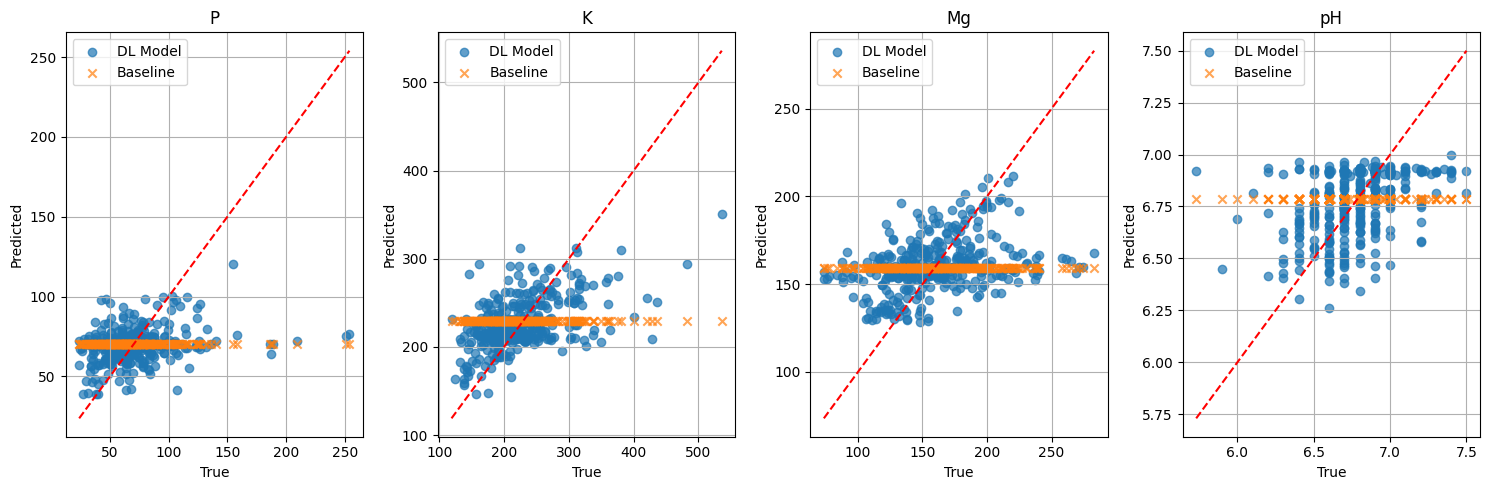

In [35]:
# Load the best model weights for the deep learning model
model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# Evaluate the deep learning model
dl_y_test_pred, dl_y_test_true, dl_model_mse_targets = evaluate_dl_model(model, test_loader, scaler_y, device)

# Evaluate the baseline regressor (using the globally available y_test_true from inverse scaling test_dataset labels)
baseline_y_test_pred, baseline_mse_targets = evaluate_baseline_regressor(baseline_reg_current, X_test_filtered, y_test_true)

# Calculate and print combined results, including plotting
calculate_and_print_results(dl_model_mse_targets, baseline_mse_targets, y_test_true, dl_y_test_pred, baseline_y_test_pred)

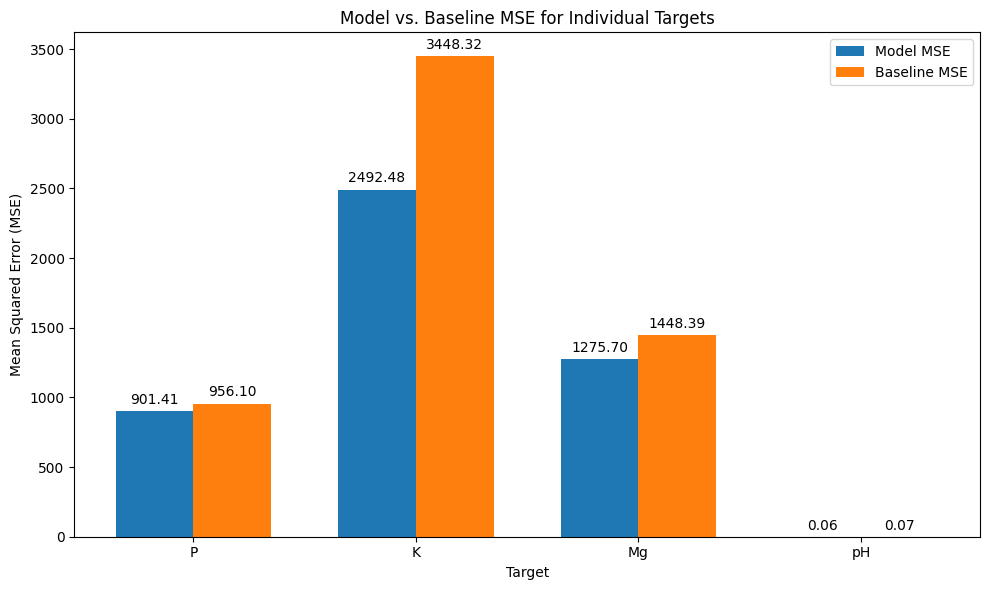

In [36]:
import matplotlib.pyplot as plt
import numpy as np

target_names = ["P", "K", "Mg", "pH"]

# Get the MSEs from the kernel state
# Assuming model_mse_targets and baseline_mse_targets are available from previous execution
model_mse_targets = np.array(model_mse_targets) # Ensure it's a numpy array for indexing
baseline_mse_targets = np.array(baseline_mse_targets) # Ensure it's a numpy array for indexing

x = np.arange(len(target_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, model_mse_targets, width, label='Model MSE')
rects2 = ax.bar(x + width/2, baseline_mse_targets, width, label='Baseline MSE')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Target')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Model vs. Baseline MSE for Individual Targets')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()